In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
from google.colab import data_table
from vega_datasets import data
data_table.enable_dataframe_formatter()


In [ ]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import warnings
warnings.filterwarnings('ignore')

In [ ]:
##Import the modules
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing
import matplotlib.pyplot as plt
#-----------------------------------------------------##
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn import ensemble
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel, Matern

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
from scipy.stats import norm
from scipy.stats import skew,kurtosis

In [ ]:
import csv
import os
from sklearn.cross_decomposition import PLSRegression
from sklearn import svm
from sklearn.svm import SVR


In [ ]:
pd.set_option('display.max_rows',1000)
pd.set_option('display.max_columns', 1000)


In [ ]:
Descriptor = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/GaBP2/GaBP2_2024/5_regression/1_SISSO_features_Complexity_5/ABX2_complexity5_3D.csv")
#Descriptor = pd.read_csv("ABX2_complexity5_3D.csv")
Descriptor.sample(2)

,compound,BandGap,Volume,vand_rad_Avg,vand_rad_Min,vand_rad_Max,cov_rad_Avg,cov_rad_Min,cov_rad_Max,atom_rad_Avg,atom_rad_Min,atom_rad_Max,density_Avg,density_Min,density_Max,d001,d002,d003,bandgap_SISSO
49,ZnSnN2,0.97,213.04,170.33,139,217,110.67,71,139,115.0,65,145,5.08,0.81,7.31,21.191304,-10219.910118,-0.000346,0.907431
17,AlInN2,3.00,203.20,177.33,155,193,111.33,71,142,115.0,65,155,3.61,0.81,7.31,31.533260,-8060.657208,-0.001932,2.780407


In [ ]:
import pandas as pd
import re

# Function to extract the last element from the compound string
def extract_family(compound):
    elements = re.findall(r'[A-Z][a-z]?', compound)
    return elements[-1] if elements else None

# Apply the function to create a new 'Family' column
Descriptor['Family'] = Descriptor['compound'].apply(extract_family)

# Show result
Descriptor.head(2)

,compound,BandGap,Volume,vand_rad_Avg,vand_rad_Min,vand_rad_Max,cov_rad_Avg,cov_rad_Min,cov_rad_Max,atom_rad_Avg,atom_rad_Min,atom_rad_Max,density_Avg,density_Min,density_Max,d001,d002,d003,bandgap_SISSO,Family
0,ZnGeN2,2.44,181.39,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,26.743211,-3767.725011,-0.017962,2.735238,N
1,ZnGeN2,3.02,181.83,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,26.693666,-3767.725011,-0.017962,2.727145,N


In [ ]:
Descriptor = Descriptor.drop(['d001', 'd002', 'd003', 'bandgap_SISSO'], axis=1)

In [ ]:
Descriptor.keys()

Index(['compound', 'BandGap', 'Volume', 'vand_rad_Avg', 'vand_rad_Min',
       'vand_rad_Max', 'cov_rad_Avg', 'cov_rad_Min', 'cov_rad_Max',
       'atom_rad_Avg', 'atom_rad_Min', 'atom_rad_Max', 'density_Avg',
       'density_Min', 'density_Max', 'Family'],
      dtype='object')

In [ ]:
Descriptor1 = Descriptor.copy()
Descriptor1=Descriptor1.round(decimals =2)
Descriptor1 = Descriptor1[~Descriptor1['compound'].str.contains('ZnSiP2', case=False)]
Descriptor1.head(2)

,compound,BandGap,Volume,vand_rad_Avg,vand_rad_Min,vand_rad_Max,cov_rad_Avg,cov_rad_Min,cov_rad_Max,atom_rad_Avg,atom_rad_Min,atom_rad_Max,density_Avg,density_Min,density_Max,Family
0,ZnGeN2,2.44,181.39,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,N
1,ZnGeN2,3.02,181.83,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,N


In [ ]:
ML_data = Descriptor1.copy()
ML_data['radious_avg']=  ML_data[['vand_rad_Avg','cov_rad_Avg','atom_rad_Avg']].mean(axis=1)
ML_data = ML_data.round(decimals = 2)
ML_data.head(2)

,compound,BandGap,Volume,vand_rad_Avg,vand_rad_Min,vand_rad_Max,cov_rad_Avg,cov_rad_Min,cov_rad_Max,atom_rad_Avg,atom_rad_Min,atom_rad_Max,density_Avg,density_Min,density_Max,Family,radious_avg
0,ZnGeN2,2.44,181.39,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,N,127.0
1,ZnGeN2,3.02,181.83,168.33,139,211,104.33,71,122,108.33,65,135,4.42,0.81,7.13,N,127.0


In [ ]:
(168.33+104.33+108.33)/3

126.99666666666667

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
#import umap
from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import IsolationForest
# from scipy.cluster.hierarchy import dendrogram, linkage

# Load data
df = ML_data.copy()  # Assuming ML_data1 is already in memory


In [ ]:
# Select only numerical columns for analysis (exclude 'material')
features = df[['BandGap', 'Volume','radious_avg','density_Avg']]
features = features.round(decimals = 2)

In [ ]:
#features = df[['BandGap', 'Volume','vand_rad_Avg','cov_rad_Avg','atom_rad_Avg','density_Avg']]
#features = df[['BandGap', 'Volume']]
#features = Descriptor[['d001', 'd002', 'd003']]
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(features1)  # Standardize data
X_scaled = features.copy()

# K-Means Clustering

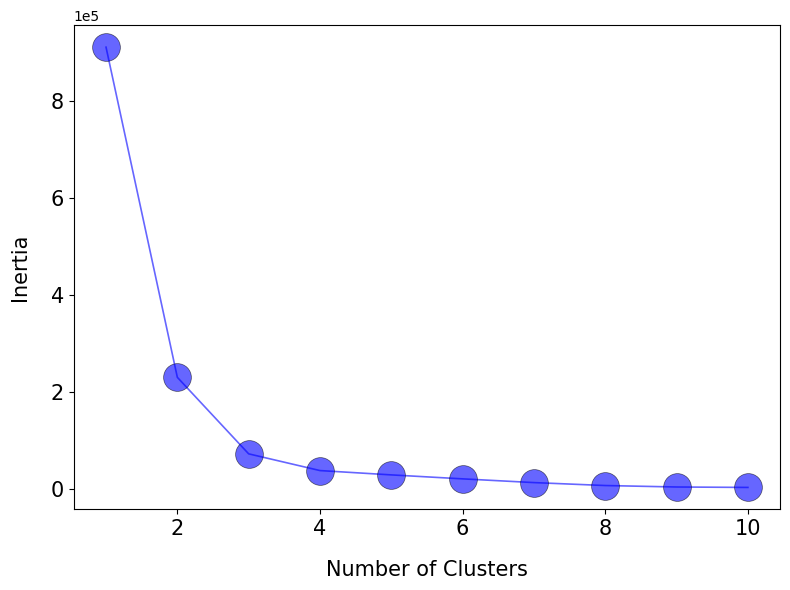

In [ ]:
# Determine the optimal number of clusters using the Elbow Method
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
#plt.figure(figsize=(10, 7),dpi=400)
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o', markeredgecolor='black', markersize=20,color='blue',markeredgewidth=0.5,linewidth=1.2,alpha=0.6)
plt.xlabel("Number of Clusters", fontsize=15,labelpad=15)
plt.ylabel("Inertia", fontsize=15,labelpad=15)
plt.xticks(fontsize=15) # Adjust the size as needed
plt.yticks(fontsize=15) # Adjust the size as needed
#plt.tick_params(axis='both', which='major', labelsize=15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.title("Elbow Method for Optimal K")
plt.tight_layout()
plt.savefig ('Elbow.pdf')
plt.show()


In [ ]:
from google.colab import files
files.download("Elbow.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Silhouette Score:

In [ ]:
from sklearn.metrics import silhouette_score



In [ ]:
scores = {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

print(scores)


{2: np.float64(0.7139627929372061), 3: np.float64(0.7017472521400551), 4: np.float64(0.6876743855855726), 5: np.float64(0.6984522611903279), 6: np.float64(0.6812964886227393), 7: np.float64(0.6401893397310034), 8: np.float64(0.7094376799474783), 9: np.float64(0.7465400329130125)}


In [ ]:
Descriptor.keys()

Index(['compound', 'BandGap', 'Volume', 'vand_rad_Avg', 'vand_rad_Min',
       'vand_rad_Max', 'cov_rad_Avg', 'cov_rad_Min', 'cov_rad_Max',
       'atom_rad_Avg', 'atom_rad_Min', 'atom_rad_Max', 'density_Avg',
       'density_Min', 'density_Max', 'Family'],
      dtype='object')

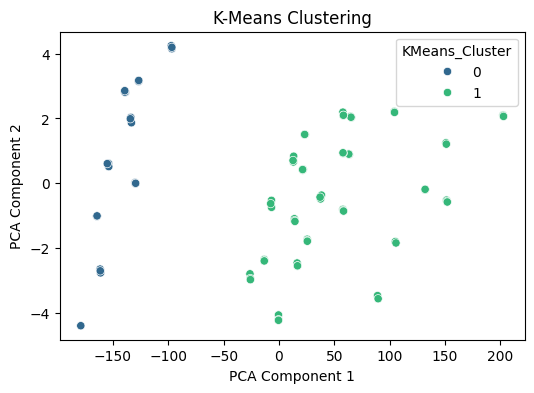

In [ ]:
# Fit KMeans with optimal K (assuming 3 from elbow method)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
df['Family'] = Descriptor['Family'].copy()
# Plot clusters using PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = X_pca[:, 0], X_pca[:, 1]
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['KMeans_Cluster'], palette='viridis')
# ## Make wrt to bandgap
# sc =plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['BandGap'], cmap='Set1', s=50, edgecolor='k')
# # Add colorbar
# cbar = plt.colorbar(sc)
# cbar.set_label('bandgap (eV)', fontsize=12)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clustering")
plt.show()


In [ ]:
score = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(round(score, 3))

0.714


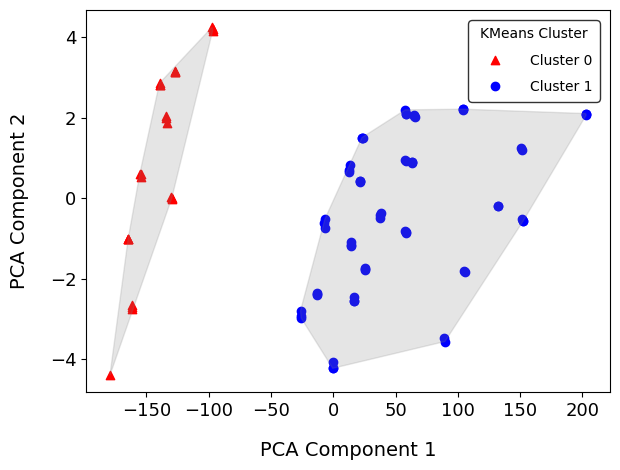

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import ConvexHull
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
#plt.figure(figsize=(6.3, 4.8),dpi=400)
plt.figure(figsize=(6.3, 4.8))
# Define custom colors and markers
colors = ['red', 'blue', 'brown']
markers = [ '^','o', 'D']

# Sort cluster labels to ensure order 0, 1, 2
sorted_clusters = sorted(df['KMeans_Cluster'].unique())

# Plot each cluster separately to control marker styles
for cluster, color, marker in zip(sorted_clusters, colors, markers):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'],
                label=f'Cluster {cluster}', color=color, marker=marker)

# Draw convex hulls around each cluster
for cluster in sorted_clusters:
    cluster_points = df[df['KMeans_Cluster'] == cluster][['PCA1', 'PCA2']].values
    if len(cluster_points) >= 2:  # ConvexHull needs at least 2 points
        hull = ConvexHull(cluster_points)
        hull_vertices = cluster_points[hull.vertices]
        plt.fill(hull_vertices[:, 0], hull_vertices[:, 1], alpha=0.2, color='gray')
# Customize axis labels and ticks
plt.tick_params(axis='both', which='major', labelsize=13)
plt.xlabel("PCA Component 1", fontsize=14, labelpad=15)
plt.ylabel("PCA Component 2", fontsize=14, labelpad=15)
# Customize legend
legend = plt.legend(title="KMeans Cluster", loc='upper right', prop={'size': 14}, frameon=True)
legend.get_frame().set_edgecolor('black')  # Make legend border black
for text in legend.get_texts():
    text.set_fontsize(10)  # Set legend label text size
## Make wrt to bandgap
#sc =plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['BandGap'], cmap='Set1', s=50, edgecolor='k')
# Add colorbar
#cbar = plt.colorbar(sc)
#cbar.set_label('bandgap (eV)', fontsize=12)
plt.tight_layout()
#plt.savefig ('Kmeans_cluster.pdf')
plt.show()


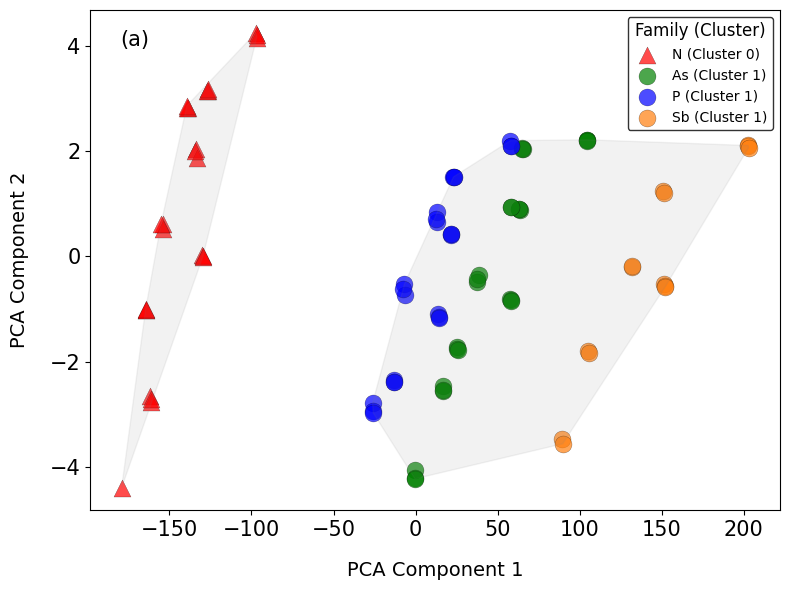

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

#plt.figure(figsize=(8, 6),dpi=400)

plt.figure(figsize=(8, 6))
# --- Cluster markers (shapes) ---
cluster_markers = ['^', 'o', 'D', '*']  # adjust if more clusters
sorted_clusters = sorted(df['KMeans_Cluster'].unique())

# --- Define specific colors for families ---
unique_families = df['Family'].unique()
manual_colors = ['red', 'green', 'blue', 'tab:orange']  # your chosen colors

# Repeat colors if there are more families than colors
from itertools import cycle
color_cycle = cycle(manual_colors)
family_colors = [next(color_cycle) for _ in range(len(unique_families))]

# Map families to colors
family_color_map = dict(zip(unique_families, family_colors))

# --- Plot each cluster/family combination ---
for cluster, marker in zip(sorted_clusters, cluster_markers):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    for family in unique_families:
        family_data = cluster_data[cluster_data['Family'] == family]
        if not family_data.empty:
            plt.scatter(family_data['PCA1'], family_data['PCA2'],
                        color=family_color_map[family],
                        marker=marker,
                        s=150,
                        label=f"{family} (Cluster {cluster})", alpha=0.7,edgecolor='black',
                         linewidth=0.2   )

# --- Draw convex hulls per cluster ---
for cluster in sorted_clusters:
    cluster_points = df[df['KMeans_Cluster'] == cluster][['PCA1', 'PCA2']].values
    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        hull_vertices = cluster_points[hull.vertices]
        plt.fill(hull_vertices[:, 0], hull_vertices[:, 1], alpha=0.1, color='gray')

# --- Axis labels and ticks ---
#plt.tick_params(axis='both', which='major', labelsize=13)
plt.xlabel("PCA Component 1", fontsize=14, labelpad=15)
plt.ylabel("PCA Component 2", fontsize=14, labelpad=15)
plt.xticks(fontsize=15) # Adjust the size as needed
plt.yticks(fontsize=15) # Adjust the size as needed
# --- Legend: remove duplicates, black border ---
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),
           title="Family (Cluster)", fontsize=10, title_fontsize=12,
           loc='upper right', frameon=True, edgecolor='black')
plt.text(-180, 4, '(a)',fontsize=15)
plt.tight_layout()
plt.savefig ('Kmeans_cluster.pdf')
plt.show()


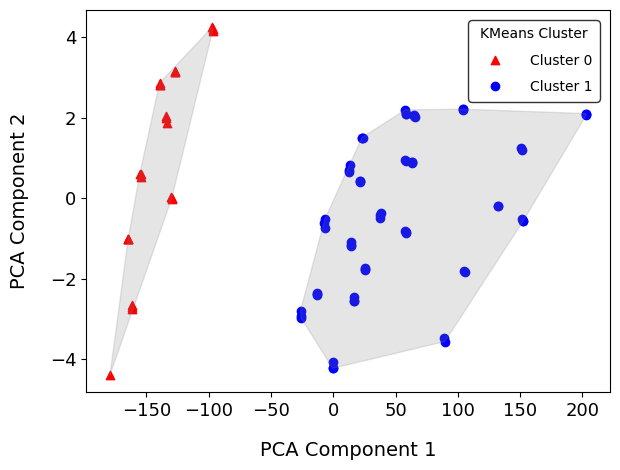

In [ ]:
# from google.colab import files
# files.download("Kmeans_cluster.pdf")

# I want to take only feature, which used in x_scaled

In [ ]:
df.keys()

Index(['compound', 'BandGap', 'Volume', 'vand_rad_Avg', 'vand_rad_Min',
       'vand_rad_Max', 'cov_rad_Avg', 'cov_rad_Min', 'cov_rad_Max',
       'atom_rad_Avg', 'atom_rad_Min', 'atom_rad_Max', 'density_Avg',
       'density_Min', 'density_Max', 'Family', 'radious_avg', 'KMeans_Cluster',
       'PCA1', 'PCA2'],
      dtype='object')

In [ ]:
df1 = df[['BandGap', 'Volume', 'radious_avg', 'density_Avg','KMeans_Cluster']]
df1.head()

,BandGap,Volume,radious_avg,density_Avg,KMeans_Cluster
0,2.44,181.39,127.00,4.42,0
1,3.02,181.83,127.00,4.42,0
2,2.73,181.56,127.00,4.42,0
3,4.59,178.46,128.89,3.14,0
4,4.63,178.36,128.89,3.14,0


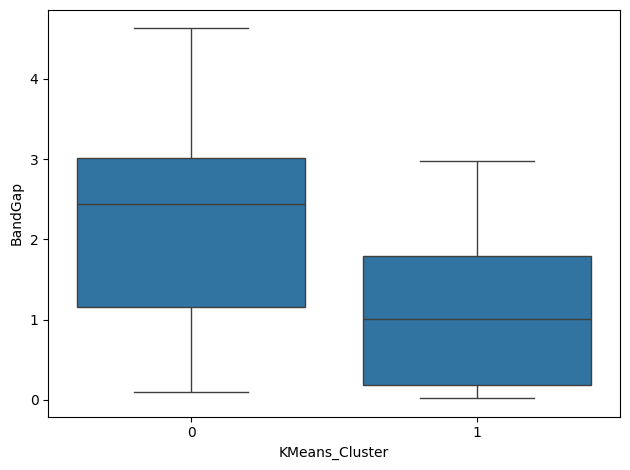

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Box plot for BandGap by cluster
#plt.figure(figsize=(12, 5))
sns.boxplot(x='KMeans_Cluster', y='BandGap', data=df)
plt.tight_layout()
plt.show()


In [ ]:
# Group by cluster and calculate mean and median
mean_df = df1.groupby('KMeans_Cluster').mean(numeric_only=True)
median_df = df1.groupby('KMeans_Cluster').median(numeric_only=True)

In [ ]:
# Concatenate mean and median with multi-level columns
combined = pd.concat([mean_df, median_df], keys=['Mean', 'Median'])
# To make it easier to read, you can transpose:
combined = combined.transpose()
print(combined)


                    Mean              Median         
KMeans_Cluster         0           1       0        1
BandGap           2.2300    1.109063    2.44    1.010
Volume          202.7280  396.871719  203.87  380.300
radious_avg     132.3560  146.685781  132.00  146.220
density_Avg       4.3824    5.643281    4.42    5.495


In [ ]:
median_df.T.round(decimals = 2)

KMeans_Cluster,0,1
BandGap,2.44,1.01
Volume,203.87,380.30
radious_avg,132.00,146.22
density_Avg,4.42,5.50
